# Regression

The dataset we are using is designed for classification algorithms. The question is:

**Can we predict some continuous variable from the dataset?**

In [11]:
import pandas as pd
import seaborn as sns
import sys
sys.path.append("..")
from src.models.regression.ranking import rank_targets_by_r2
import matplotlib.pyplot as plt

In [10]:
# Load the raw and processed datasets. 
# We want to know which dataset is a better cadidate for building a model
df_original = pd.read_csv("../data/raw/heart_failure_clinical_records_dataset.csv")
df_processed = pd.read_csv("../data/processed/heart_failure_clinical_records_dataset_processed.csv")

ranking_original = rank_targets_by_r2(df_original)
ranking_processed = rank_targets_by_r2(df_processed)

print("Original dataset")
display(ranking_original)

print("Processed dataset")
display(ranking_processed)

Original dataset


,target,mean_r2,std_r2
9,sex,0.188487,0.057590
10,smoking,0.139531,0.084165
4,ejection_fraction,0.032069,0.095801
7,serum_creatinine,-0.020748,0.053399
8,serum_sodium,-0.025713,0.075691
0,age,-0.060288,0.109303
2,creatinine_phosphokinase,-0.075312,0.136622
1,anaemia,-0.082587,0.076968
5,high_blood_pressure,-0.098460,0.073956
6,platelets,-0.099267,0.123842


Processed dataset


,target,mean_r2,std_r2
15,age_diabetes_interaction,0.961329,0.012306
2,diabetes,0.960939,0.014049
10,creatinine_log,0.940599,0.033978
16,sodium_creatinine_interaction,0.905686,0.039173
14,ejection_creatinine_interaction,0.715337,0.184296
12,ejection_fraction_centered,0.311037,0.334829
11,age_centered,0.237094,0.044333
6,sex,0.171458,0.069564
7,smoking,0.133907,0.079991
5,serum_sodium,-0.003059,0.088567


To identify a suitable regression target, we evaluated the predictability
of each numeric variable using cross-validated R².

Several engineered variables show very high R² values, but these are
deterministic transformations or interaction terms derived from other
features and therefore are not meaningful regression targets.

Binary variables such as `diabetes` also show high predictability, but
these correspond to classification problems rather than regression tasks.

Among the original continuous clinical variables, `ejection_fraction`
exhibits the highest predictive signal (R² ≈ 0.31), while other variables
such as serum sodium, platelets, or creatinine phosphokinase show little
or no predictive structure.

For this reason, `ejection_fraction` was selected as the target variable
for the regression experiment.


Text(0.5, 0, 'Ejection fraction')

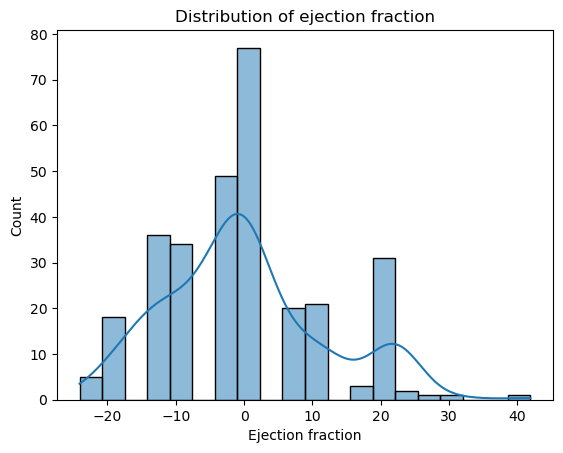

In [16]:
# We look at the distribution of the target 
sns.histplot(df_processed["ejection_fraction_centered"], bins=20, kde=True)
plt.title("Distribution of ejection fraction")
plt.xlabel("Ejection fraction")

The target variable (centered ejection fraction) shows a roughly symmetric distribution with moderate dispersion and a few high-value observations.
This suggests that regression models are appropriate, although the presence of some outliers may slightly affect model performance.

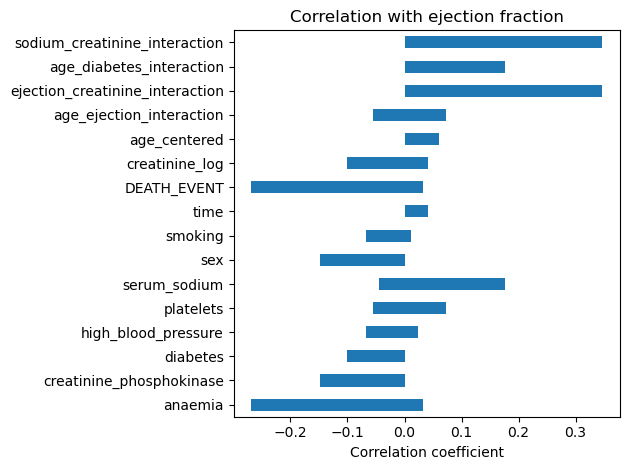

In [20]:
# We look at correlations with the target
# Exclude the target itself and the original ejection fraction column to avoid perfect correlation

corr = df_processed.corr(numeric_only=True)["ejection_fraction_centered"].drop(
    ["ejection_fraction_centered"]
)

corr.sort_values().plot(kind="barh")

corr.plot(kind="barh")
plt.title("Correlation with ejection fraction")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

The correlation analysis reveals that no single predictor exhibits a strong
linear relationship with the target variable.

The highest correlations (|r| ≈ 0.3–0.35) are observed for interaction terms
introduced during feature engineering, suggesting that combinations of
clinical variables capture more information than individual predictors.

Most raw variables show weak correlations with the target, indicating that
the regression task is inherently challenging and that model performance
is expected to be moderate.

The moderate correlations suggest that linear models alone may not fully capture the relationships in the data, motivating the use of more flexible regression methods such as Random Forest or KNN regression.